# Exploratory Data Analysis (EDA)


## Objective

This notebook explores the structure and statistical properties of the training dataset.

The goals are to:

- understand the dataset schema and row-level meaning,
- examine player roles and tracking variables,
- analyze the target structure,
- inspect spatial and temporal characteristics,
- and identify patterns that will guide feature engineering and modeling.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path("..").resolve()))

from src.data_loader import list_train_files, load_train_week

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

##  Load a Sample Training Week

We load a single weekly training file to perform exploratory analysis efficiently.

In [3]:
train_files = list_train_files()
df = load_train_week(train_files[0])

print("Loaded file:", train_files[0].name)
print("Dataset shape:", df.shape)

display(df.head())

Loaded file: input_2023_w01.csv
Dataset shape: (285714, 23)


,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,player_birth_date,player_position,player_side,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,1999-09-07,FS,Defense,Defensive Coverage,52.33,36.94,0.09,0.39,322.40,238.24,21,63.259998,-0.22
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,1999-09-07,FS,Defense,Defensive Coverage,52.33,36.94,0.04,0.61,200.89,236.05,21,63.259998,-0.22
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,1999-09-07,FS,Defense,Defensive Coverage,52.33,36.93,0.12,0.73,147.55,240.60,21,63.259998,-0.22
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,1999-09-07,FS,Defense,Defensive Coverage,52.35,36.92,0.23,0.81,131.40,244.25,21,63.259998,-0.22
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,1999-09-07,FS,Defense,Defensive Coverage,52.37,36.90,0.35,0.82,123.26,244.25,21,63.259998,-0.22


##  Dataset Overview

Each row appears to represent a player observed at a specific frame within a play.

In [4]:
print("Number of unique games:", df["game_id"].nunique())
print("Number of unique plays:", df["play_id"].nunique())
print("Number of unique players:", df["nfl_id"].nunique())
print("Number of unique frames:", df["frame_id"].nunique())

Number of unique games: 16
Number of unique plays: 748
Number of unique players: 737
Number of unique frames: 74


In [5]:
print("Columns:")
print(df.columns.tolist())

Columns:
['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id', 'play_direction', 'absolute_yardline_number', 'player_name', 'player_height', 'player_weight', 'player_birth_date', 'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a', 'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y']


## Player Role Distribution

We inspect the distribution of player roles to understand the composition of the dataset.

In [6]:
print(df["player_role"].value_counts())
print("\nNormalized:")
print(df["player_role"].value_counts(normalize=True))

Defensive Coverage    155397
Other Route Runner     84063
Targeted Receiver      23151
Passer                 23103
Name: player_role, dtype: int64

Normalized:
Defensive Coverage    0.543890
Other Route Runner    0.294221
Targeted Receiver     0.081029
Passer                0.080861
Name: player_role, dtype: float64


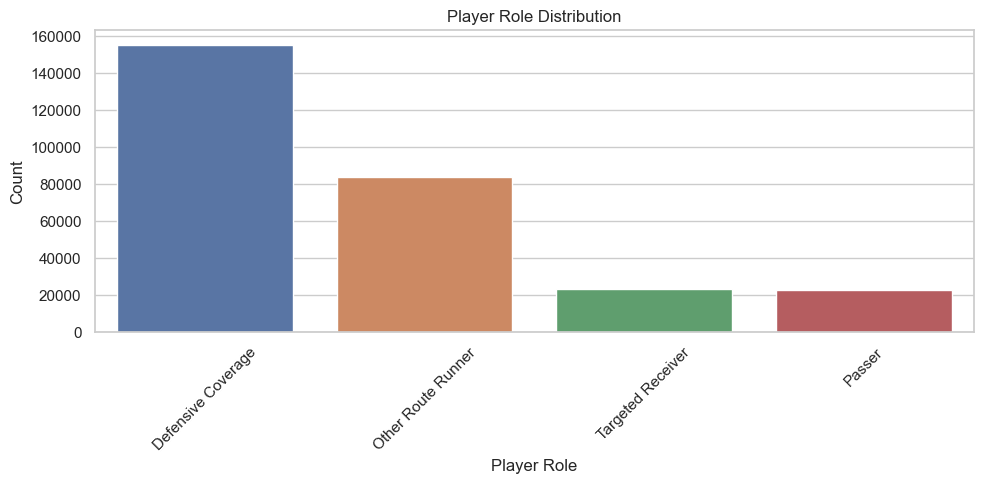

In [7]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="player_role", order=df["player_role"].value_counts().index)
plt.title("Player Role Distribution")
plt.xlabel("Player Role")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Target Indicator Analysis

The column `player_to_predict` identifies the primary target rows for prediction.

In [8]:
print("Target counts:")
print(df["player_to_predict"].value_counts())

print("\nTarget proportions:")
print(df["player_to_predict"].value_counts(normalize=True))

print("\nPercentage of target rows:", df["player_to_predict"].mean())

Target counts:
False    209315
True      76399
Name: player_to_predict, dtype: int64

Target proportions:
False    0.732603
True     0.267397
Name: player_to_predict, dtype: float64

Percentage of target rows: 0.2673967673967674


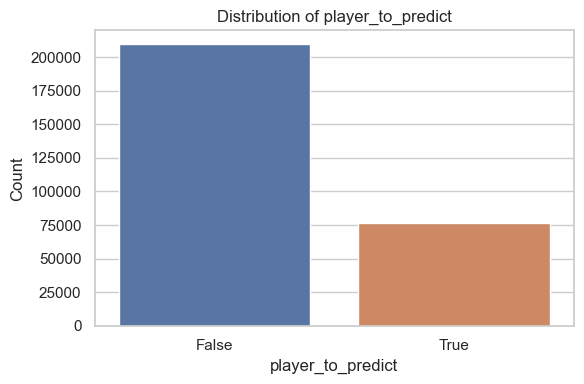

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="player_to_predict")
plt.title("Distribution of player_to_predict")
plt.xlabel("player_to_predict")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [10]:
display(df[df["player_to_predict"] == True].head())


,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,player_birth_date,player_position,player_side,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
26,2023090700,101,True,46137,1,right,42,Justin Reid,6-1,204,1997-02-15,SS,Defense,Defensive Coverage,51.32,20.69,0.31,0.49,79.43,267.68,21,63.259998,-0.22
27,2023090700,101,True,46137,2,right,42,Justin Reid,6-1,204,1997-02-15,SS,Defense,Defensive Coverage,51.35,20.66,0.36,0.74,118.07,268.66,21,63.259998,-0.22
28,2023090700,101,True,46137,3,right,42,Justin Reid,6-1,204,1997-02-15,SS,Defense,Defensive Coverage,51.39,20.63,0.44,0.76,130.89,269.78,21,63.259998,-0.22
29,2023090700,101,True,46137,4,right,42,Justin Reid,6-1,204,1997-02-15,SS,Defense,Defensive Coverage,51.43,20.61,0.48,0.62,134.50,269.78,21,63.259998,-0.22
30,2023090700,101,True,46137,5,right,42,Justin Reid,6-1,204,1997-02-15,SS,Defense,Defensive Coverage,51.48,20.58,0.54,0.44,129.79,269.06,21,63.259998,-0.22


## Target-Related Variables

We inspect the distributions of `ball_land_x`, `ball_land_y`, and `num_frames_output`.

In [11]:
display(df[["ball_land_x", "ball_land_y", "num_frames_output"]].describe())

,ball_land_x,ball_land_y,num_frames_output
count,285714.000000,285714.000000,285714.000000
mean,60.851685,26.215487,11.298669
std,25.759902,15.275341,5.727945
min,1.330000,-1.690000,5.000000
25%,41.730000,12.640000,8.000000
50%,59.060001,25.450001,10.000000
75%,78.970001,39.250000,13.000000
max,119.779999,57.330002,94.000000


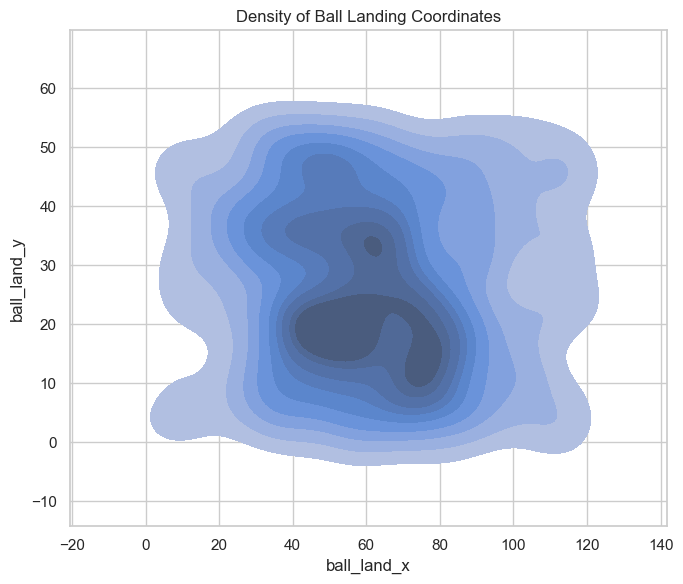

In [12]:
target_rows = df[df["player_to_predict"] == True].copy()
sample_target_rows = target_rows.sample(min(2000, len(target_rows)), random_state=42)

plt.figure(figsize=(7, 6))
sns.kdeplot(
    data=sample_target_rows,
    x="ball_land_x",
    y="ball_land_y",
    fill=True
)
plt.title("Density of Ball Landing Coordinates")
plt.xlabel("ball_land_x")
plt.ylabel("ball_land_y")
plt.tight_layout()
plt.show()

##  Tracking Variables

The main movement variables include position, speed, acceleration, direction, and orientation.

In [13]:
tracking_cols = ["x", "y", "s", "a", "dir", "o"]
display(df[tracking_cols].describe())

,x,y,s,a,dir,o
count,285714.000000,285714.000000,285714.000000,285714.000000,285714.000000,285714.000000
mean,60.466355,26.751004,3.041966,2.126249,177.926268,181.198227
std,24.007917,10.035753,2.231126,1.430355,100.934248,98.972312
min,1.210000,0.970000,0.000000,0.000000,0.000000,0.000000
25%,41.630000,18.900000,1.120000,1.010000,89.530000,89.930000
50%,58.810000,26.710000,2.730000,1.920000,173.365000,182.230000
75%,78.520000,34.530000,4.650000,3.050000,269.580000,271.320000
max,119.860000,52.430000,12.530000,17.120000,359.990000,359.990000


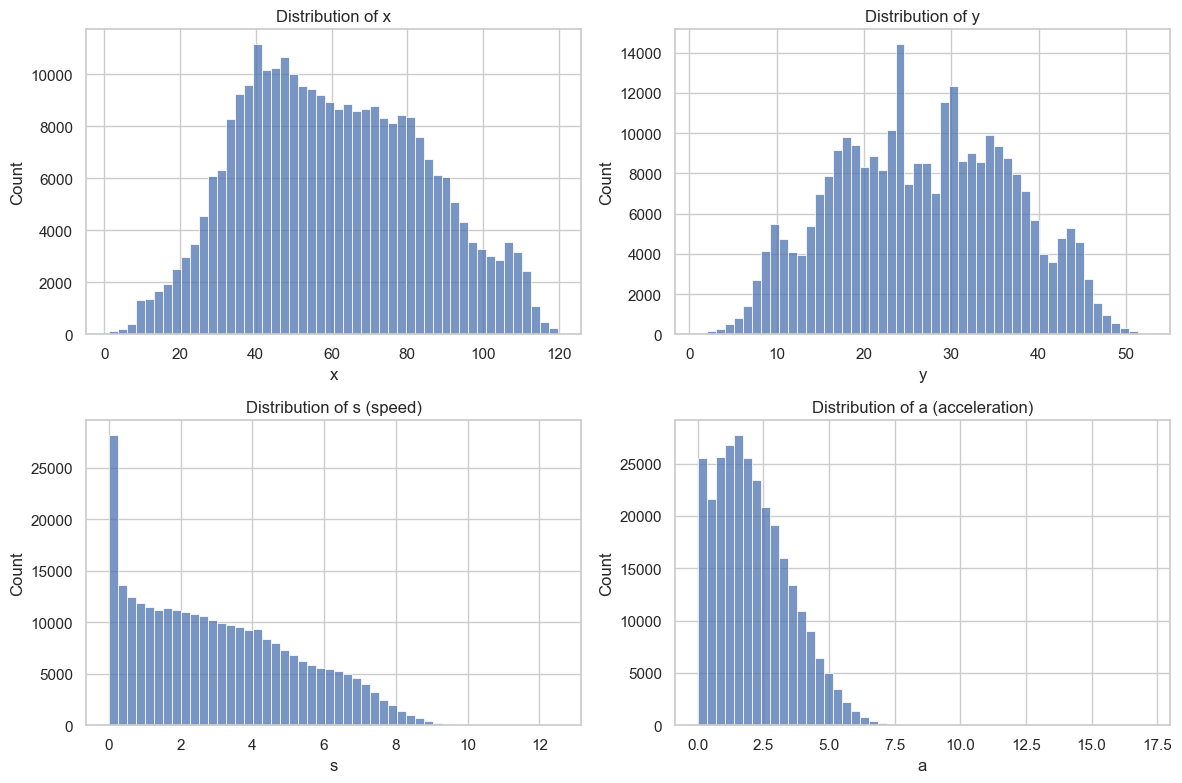

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["x"], bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of x")

sns.histplot(df["y"], bins=50, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of y")

sns.histplot(df["s"], bins=50, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of s (speed)")

sns.histplot(df["a"], bins=50, ax=axes[1, 1])
axes[1, 1].set_title("Distribution of a (acceleration)")

plt.tight_layout()
plt.show()

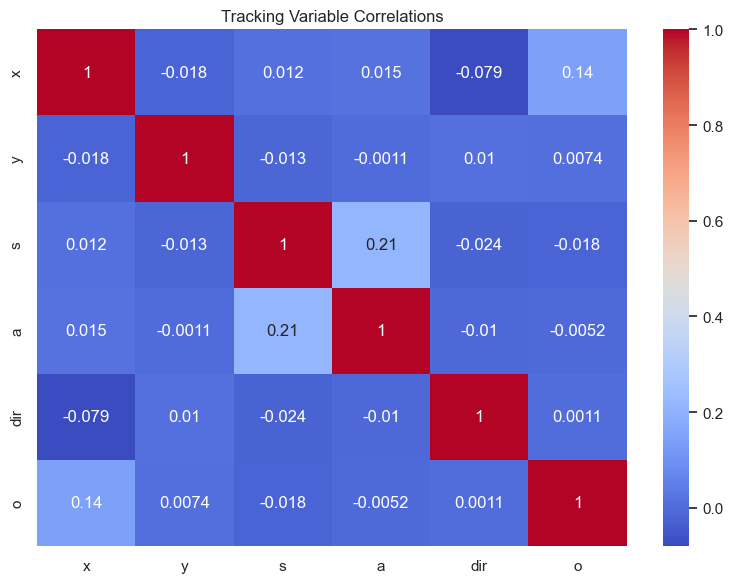

In [15]:
corr = df[tracking_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Tracking Variable Correlations")
plt.tight_layout()
plt.show()

## Field Position Distribution

We inspect player coordinates across the field to confirm that tracking positions behave as expected spatially.

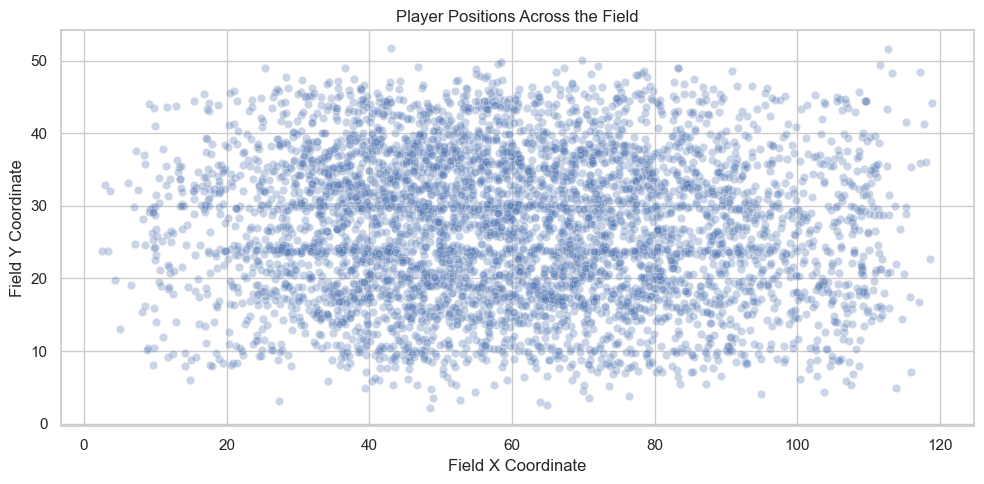

In [16]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="x",
    y="y",
    alpha=0.3
)
plt.title("Player Positions Across the Field")
plt.xlabel("Field X Coordinate")
plt.ylabel("Field Y Coordinate")
plt.tight_layout()
plt.show()

##  Temporal Structure

We inspect the number of frames per play to understand temporal coverage.

In [17]:
frames_per_play = (
    df.groupby(["game_id", "play_id"])["frame_id"]
    .nunique()
    .reset_index(name="num_frames")
)

display(frames_per_play.head())
display(frames_per_play["num_frames"].describe())

,game_id,play_id,num_frames
0,2023090700,101,26
1,2023090700,194,32
2,2023090700,219,17
3,2023090700,361,51
4,2023090700,436,20


count    819.000000
mean      28.267399
std        8.893450
min        9.000000
25%       22.000000
50%       27.000000
75%       33.000000
max       74.000000
Name: num_frames, dtype: float64

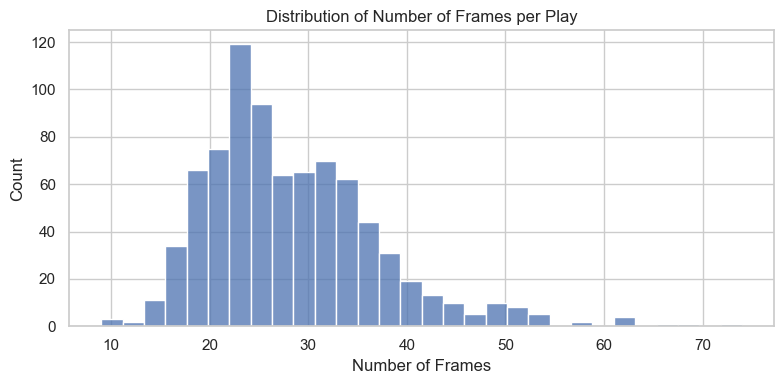

In [18]:
plt.figure(figsize=(8, 4))
sns.histplot(frames_per_play["num_frames"], bins=30)
plt.title("Distribution of Number of Frames per Play")
plt.xlabel("Number of Frames")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Missing Data Inspection

Instead of using a heatmap, we inspect missing-value percentages directly, which is more interpretable for large tracking datasets.

In [19]:
missing_percent = df.isnull().mean().sort_values(ascending=False)
display(missing_percent[missing_percent > 0])

Series([], dtype: float64)

## Summary

Key findings from this exploratory analysis:

- the dataset is organized at the player-frame level,
- `player_to_predict` defines the target rows,
- tracking variables provide rich movement information,
- ball landing variables provide spatial target context,
- and the temporal structure suggests that both frame-level and aggregated features may be useful.

These findings will guide the feature engineering and baseline modeling stages.